In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile
import glob
import pandas as pd

# Define paths matching the folder you created in Drive
drive_folder_path = '/content/drive/MyDrive/Ford-Go-bike sharing'
extract_to_path = '/content/extracted_bike_data'

# Create a local directory in Colab environment to extract files into
os.makedirs(extract_to_path, exist_ok=True)

# 1. Look for all zip files in your Drive folder
zip_files = glob.glob(os.path.join(drive_folder_path, '*.zip'))

print(f"Found {len(zip_files)} zip files. Extracting...")
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)
print("Extraction complete!")

# 2. Find all the extracted CSV files and combine them
csv_files = glob.glob(os.path.join(extract_to_path, '*.csv'))
df_list = []

print(f"Found {len(csv_files)} CSV files. Merging into one dataframe...")
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# The final combined dataset
df = pd.concat(df_list, ignore_index=True)
print(f"✅ Success! Merged dataset shape: {df.shape}")

Found 12 zip files. Extracting...
Extraction complete!
Found 11 CSV files. Merging into one dataframe...
✅ Success! Merged dataset shape: (1667753, 16)


In [ ]:
# 1. View the first 5 rows to see what the data actually looks like
print("--- DATASET SAMPLE ---")
display(df.head())

# 2. Check structure, column names, and data types
print("\n--- DATA TYPES AND NON-NULL COUNTS ---")
print(df.info())

# 3. Check for missing values in each column
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

--- DATASET SAMPLE ---


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,72393,2018-04-30 22:49:32.6180,2018-05-01 18:56:06.3010,4.0,Cyril Magnin St at Ellis St,37.785881,-122.408915,4.0,Cyril Magnin St at Ellis St,37.785881,-122.408915,3940,Customer,NaN,NaN,No
1,81034,2018-04-30 17:46:04.9970,2018-05-01 16:16:39.2470,122.0,19th St at Mission St,37.760299,-122.418892,42.0,San Francisco City Hall (Polk St at Grove St),37.778650,-122.418230,3374,Customer,NaN,NaN,No
2,86142,2018-04-30 16:07:13.9190,2018-05-01 16:02:56.7170,41.0,Golden Gate Ave at Polk St,37.781270,-122.418740,67.0,San Francisco Caltrain Station 2 (Townsend St...,37.776639,-122.395526,3191,Subscriber,1974.0,Male,Yes
3,68839,2018-04-30 17:11:57.4640,2018-05-01 12:19:16.7870,284.0,Yerba Buena Center for the Arts (Howard St at ...,37.784872,-122.400876,115.0,Jackson Playground,37.765026,-122.398773,2970,Customer,1974.0,Female,No
4,59091,2018-04-30 18:45:21.5560,2018-05-01 11:10:13.5410,196.0,Grand Ave at Perkins St,37.808894,-122.256460,233.0,12th St at 4th Ave,37.795812,-122.255555,522,Customer,1965.0,Male,No



--- DATA TYPES AND NON-NULL COUNTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1667753 entries, 0 to 1667752
Data columns (total 16 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   duration_sec             1667753 non-null  int64  
 1   start_time               1667753 non-null  object 
 2   end_time                 1667753 non-null  object 
 3   start_station_id         1658043 non-null  float64
 4   start_station_name       1658043 non-null  object 
 5   start_station_latitude   1667753 non-null  float64
 6   start_station_longitude  1667753 non-null  float64
 7   end_station_id           1658043 non-null  float64
 8   end_station_name         1658043 non-null  object 
 9   end_station_latitude     1667753 non-null  float64
 10  end_station_longitude    1667753 non-null  float64
 11  bike_id                  1667753 non-null  int64  
 12  user_type                1667753 non-null  object 
 13  me

In [ ]:
# 1. Convert time columns from text strings to actual datetime objects
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 2. Convert the trip durations from seconds to minutes
df['duration_min'] = df['duration_sec'] / 60

# 3. Drop rows where user demographics (birth year and gender) are missing
df_clean = df.dropna(subset=['member_birth_year', 'member_gender']).copy()

# 4. Calculate rider age using the year of the dataset (2018)
df_clean['member_age'] = 2018 - df_clean['member_birth_year'].astype(int)

# 5. Filter out unrealistic age records (keeping ages 90 and under)
df_clean = df_clean[df_clean['member_age'] <= 90]

# 6. Extract the specific hour and day name for peak usage analysis
df_clean['start_hour'] = df_clean['start_time'].dt.hour
df_clean['start_day'] = df_clean['start_time'].dt.day_name()

# Print execution check and dataset sizes
print("✅ Data Cleaned Successfully!")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

✅ Data Cleaned Successfully!
Original shape: (1667753, 17)
Cleaned shape: (1568365, 20)


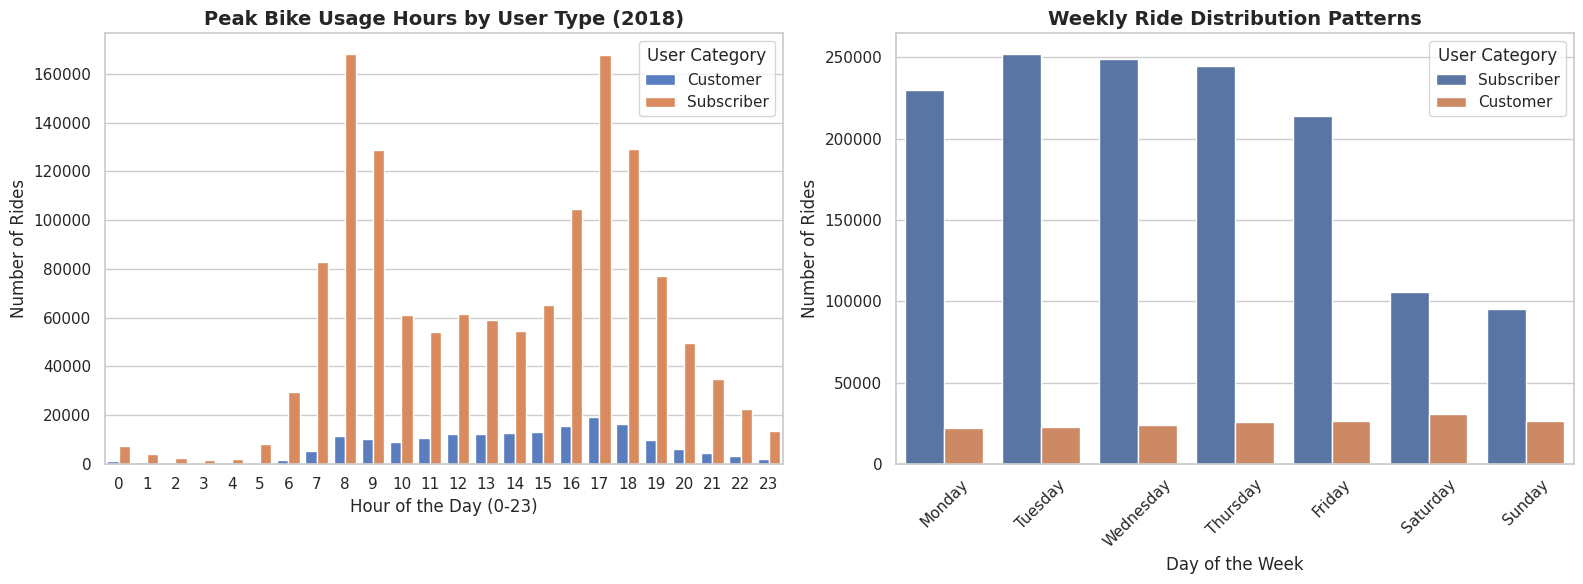

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visualization theme style
sns.set_theme(style="whitegrid")

# Create a figure canvas large enough for side-by-side graphs
plt.figure(figsize=(16, 6))

# Graph 1: Hourly Demand Analysis (Work Commute Trends)
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='start_hour', hue='user_type', palette='muted')
plt.title('Peak Bike Usage Hours by User Type (2018)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Category')

# Graph 2: Weekly Distribution Patterns (Weekdays vs Weekends)
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_clean, x='start_day', hue='user_type', order=day_order, palette='deep')
plt.title('Weekly Ride Distribution Patterns', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='User Category')

# Automatically format spacing neatly and render the plots
plt.tight_layout()
plt.show()

/tmp/ipykernel_6342/1977092620.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='user_type', y='duration_min', palette='Set2')


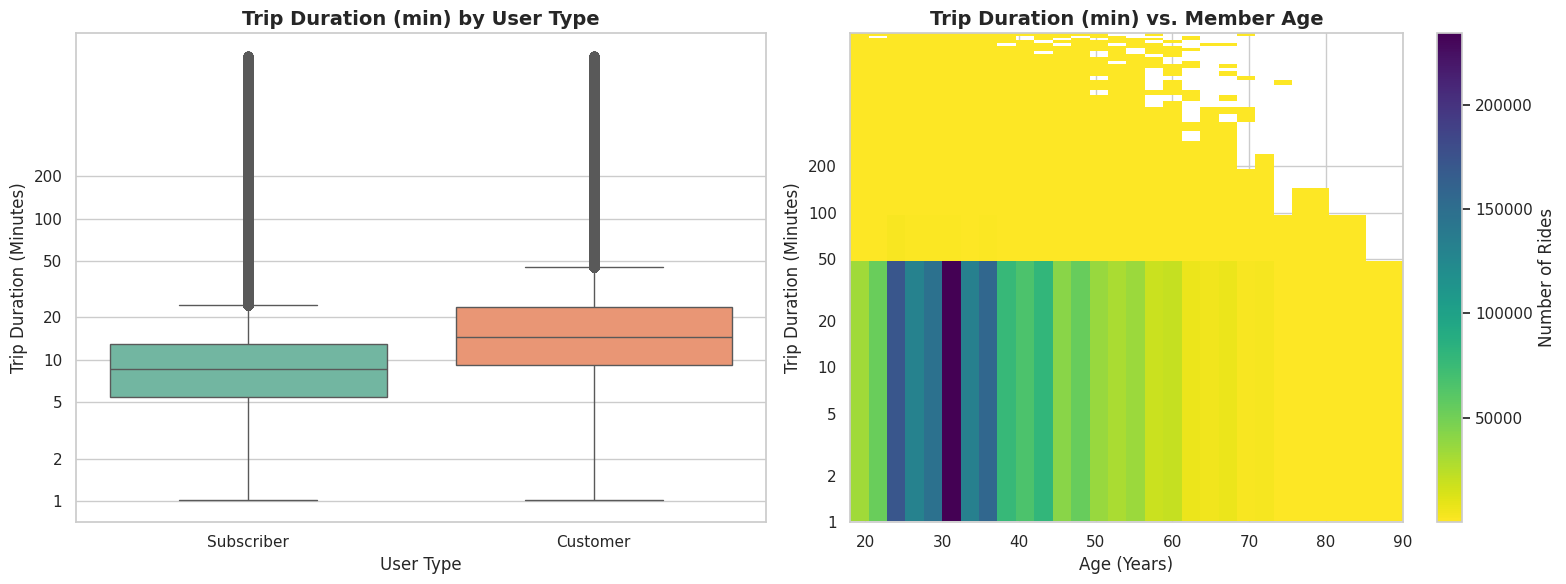

In [ ]:
# Create a figure for side-by-side bivariate plots
plt.figure(figsize=(16, 6))

# 1. Bivariate Boxplot: Trip Duration vs User Type
plt.subplot(1, 2, 1)
# Using a log scale for duration since it gives a much better visual distribution spread
sns.boxplot(data=df_clean, x='user_type', y='duration_min', palette='Set2')
plt.yscale('log')
plt.yticks([1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200])
plt.title('Trip Duration (min) by User Type', fontsize=14, fontweight='bold')
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Trip Duration (Minutes)', fontsize=12)

# 2. Bivariate Scatter/Heat Plot: Trip Duration vs Member Age
plt.subplot(1, 2, 2)
# Using a 2D histogram (heatmap style) because a regular scatter plot with 1.5M rows becomes a solid blob
plt.hist2d(data=df_clean, x='member_age', y='duration_min', bins=[30, 30], cmap='viridis_r', cmin=0.5)
plt.colorbar(label='Number of Rides')
plt.yscale('log')
plt.yticks([1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200])
plt.title('Trip Duration (min) vs. Member Age', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Trip Duration (Minutes)', fontsize=12)

plt.tight_layout()
plt.show()

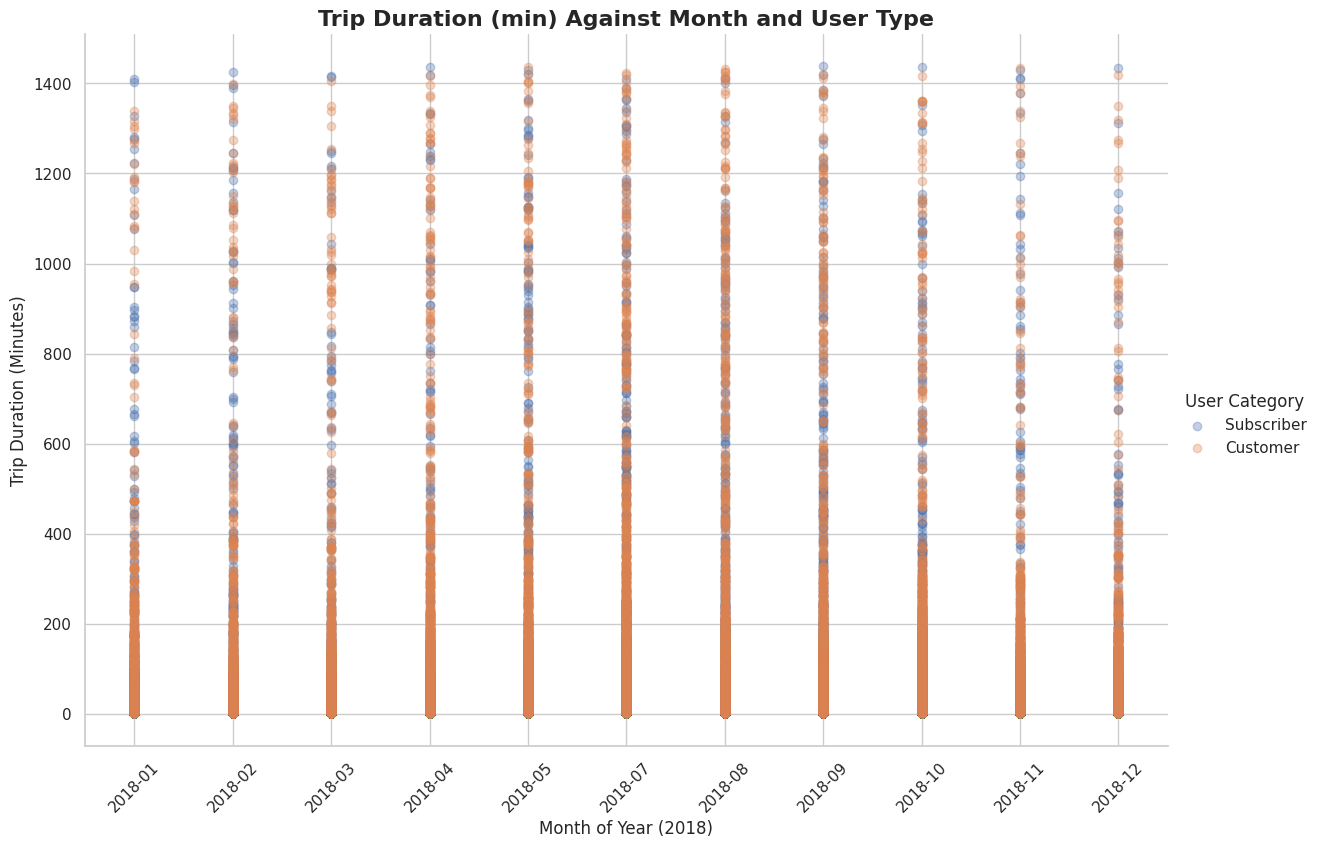

In [ ]:
# 1. Extract the starting month format required for the timeline mapping (e.g., '2018-01')
df_clean['month_start'] = df_clean['start_time'].dt.to_period('M').astype(str)

# 2. Sort values chronologically so the horizontal axis plots cleanly from January to December
df_clean = df_clean.sort_values('month_start')

# 3. Create a Multivariate FacetGrid Scatter Plot matching the sample master notebook
g = sns.FacetGrid(data=df_clean, hue='user_type', height=8, aspect=1.5)
g.map(plt.scatter, 'month_start', 'duration_min', alpha=1/3)
g.add_legend(title='User Category')

# Chart styling and labeling
plt.title('Trip Duration (min) Against Month and User Type', fontsize=16, fontweight='bold')
plt.xlabel('Month of Year (2018)', fontsize=12)
plt.ylabel('Trip Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45)

plt.show()